In [5]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv


In [6]:
load_dotenv()  # Load environment variables from .env file

True

In [7]:
LLM_Model = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0.7)

In [10]:
# creating the graph state
class LLMstate(TypedDict):
    question: str
    answer: str

In [17]:
def llm_question(state: LLMstate) -> LLMstate:
    
    # extract the question from the state
    
    question = state['question']
    
    # from question create the prompt for the LLM
    
    prompt = f"answer the following question: {question}"
    
    # give that question to LLM for response
    
    answer = LLM_Model.invoke(prompt).content
    
    # update the answer in the state
    state['answer'] = answer
    
    return state

In [18]:
#making the graph and the nodes and the edges
graph = StateGraph(LLMstate)

# nodes
graph.add_node("LLM_question", llm_question)

# edges
graph.add_edge(START, "LLM_question")
graph.add_edge("LLM_question", END)

In [19]:
# compiling the graph
workflow = graph.compile()

In [20]:
# executing the graph workflow
initial_state = {"question": "what is the capital of france? , write five lines about that"}
output_state = workflow.invoke(initial_state)

In [21]:
print(output_state)

{'question': 'what is the capital of france? , write five lines about that', 'answer': 'The capital of France is Paris. \nParis is a global center for art, fashion, and culture. \nThe city is known as the "City of Light" (La Ville Lumière) for its role in the Enlightenment and its many famous intellectuals. \nParis is home to iconic landmarks like the Eiffel Tower and Notre-Dame Cathedral. \nThe city is a popular tourist destination, attracting millions of visitors each year.'}


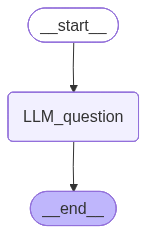

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())